# 04 Regression Analysis
## Research Topic: Sleep and SadOrHopeless

### Research Question
Does sleep duration affect the probability that a student feels sad or hopeless?


## 1. Load Libraries and Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

# 自動抓取 OneDrive 桌面的檔案路徑
user_home = os.path.expanduser("~")
possible_desktops = [
    os.path.join(user_home, "Desktop"),
    os.path.join(user_home, "OneDrive", "桌面"),
    os.path.join(user_home, "OneDrive", "Desktop"),
    os.path.join(user_home, "OneDrive - 個人", "桌面")
]

target_path = None
for d in possible_desktops:
    p = os.path.join(d, "cycle4-main", "data", "Processes", "YRBS_2007_sleep_sad_clean.csv")
    if os.path.exists(p):
        target_path = p
        break

if target_path:
    df = pd.read_csv(target_path)
    print("成功讀取！Shape:", df.shape)
    display(df.head())
else:
    print("抱歉，自動偵測還是找不到，請試試看大絕招：把檔案複製到跟這個程式同一個資料夾！")

成功讀取！Shape: (12106, 2)


,Sleep,SadOrHopeless
0,5.0,1.0
1,4.0,2.0
2,1.0,1.0
3,1.0,1.0
4,6.0,2.0


## 2. Data Preparation

Recoding:
- SadOrHopeless = 1 → Yes
- SadOrHopeless = 2 → No


In [3]:
df['sad_binary'] = np.where(
    df['SadOrHopeless']==1,
    1,
    0
)

df[['Sleep','SadOrHopeless','sad_binary']].head()


,Sleep,SadOrHopeless,sad_binary
0,5.0,1.0,1
1,4.0,2.0,0
2,1.0,1.0,1
3,1.0,1.0,1
4,6.0,2.0,0


## 3. Hypotheses

**Null Hypothesis (H₀):**
Sleep duration has no association with SadOrHopeless.

**Alternative Hypothesis (H₁):**
Sleep duration is associated with SadOrHopeless.


## 4. Logistic Regression Model

In [4]:
X = sm.add_constant(df['Sleep'])
y = df['sad_binary']

model = sm.Logit(y, X).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.595916
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             sad_binary   No. Observations:                12106
Model:                          Logit   Df Residuals:                    12104
Method:                           MLE   Df Model:                            1
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                 0.01869
Time:                        23:50:14   Log-Likelihood:                -7214.2
converged:                       True   LL-Null:                       -7351.6
Covariance Type:            nonrobust   LLR p-value:                 1.013e-61
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0504      0.058      0.863      0.388      -0.064       0.165
Sleep         -0.2475      0.

## 5. Odds Ratio

In [5]:
coef = model.params
conf = model.conf_int()

odds_ratio = np.exp(coef)

ci_lower = np.exp(conf[0])
ci_upper = np.exp(conf[1])

results = pd.DataFrame({
    'Coefficient': coef,
    'Odds Ratio': odds_ratio,
    'CI Lower': ci_lower,
    'CI Upper': ci_upper,
    'p-value': model.pvalues
})

results


,Coefficient,Odds Ratio,CI Lower,CI Upper,p-value
const,0.050371,1.051662,0.937964,1.179142,3.882075e-01
Sleep,-0.247534,0.780724,0.757920,0.804214,3.348631e-60


## 6. Visualization

### Scatter Plot


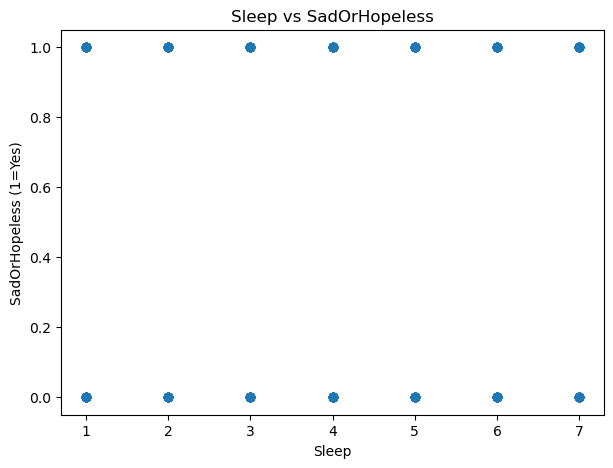

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Sleep'],
    df['sad_binary'],
    alpha=0.15
)

plt.xlabel('Sleep')
plt.ylabel('SadOrHopeless (1=Yes)')
plt.title('Sleep vs SadOrHopeless')

plt.show()


### Logistic Regression Curve

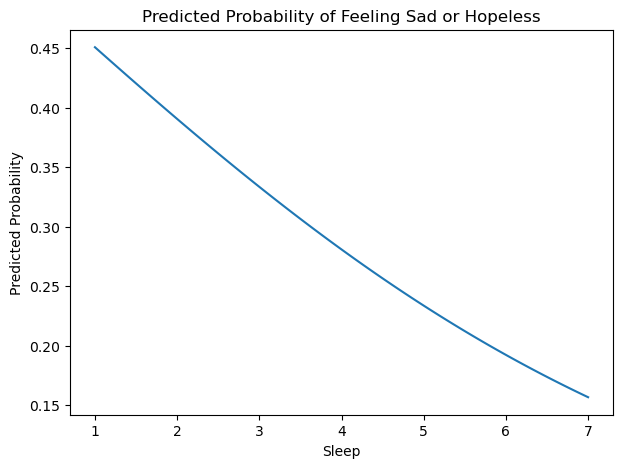

In [7]:
sleep_range = np.linspace(
    df['Sleep'].min(),
    df['Sleep'].max(),
    100
)

X_pred = sm.add_constant(sleep_range)
pred_prob = model.predict(X_pred)

plt.figure(figsize=(7,5))

plt.plot(sleep_range, pred_prob)

plt.xlabel('Sleep')
plt.ylabel('Predicted Probability')
plt.title('Predicted Probability of Feeling Sad or Hopeless')

plt.show()


## 7. Save Results

In [8]:
results.to_csv(
    'regression_summary.csv'
)

print('Results saved to regression_summary.csv')


Results saved to regression_summary.csv


## 8. Interpretation

Key items to interpret:

1. Coefficient of Sleep
2. Odds Ratio
3. p-value
4. Confidence Interval

Decision Rule:
- p-value < 0.05 → Reject H₀
- p-value ≥ 0.05 → Fail to Reject H₀

Interpret whether sleep duration significantly affects the probability of feeling sad or hopeless.
